In [ ]:
import pandas as pd

# 그래프
import seaborn as sns
import matplotlib.pyplot as plt

# ADF 정상성 여부 판단
from statsmodels.tsa.stattools import adfuller

##### 폰트 설정

In [ ]:
!apt-get install -y fonts-nanum*
!rm -rf /root/.cache/matplotlib/* # 폰트 캐시 재설정

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'fonts-nanum-extra' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum-coding' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum-eco' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum' for glob 'fonts-nanum*'
The following NEW packages will be installed:
  fonts-nanum fonts-nanum-coding fonts-nanum-eco fonts-nanum-extra
0 upgraded, 4 newly installed, 0 to remove and 34 not upgraded.
Need to get 46.0 MB of archives.
After this operation, 177 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-coding all 2.5-3 [4,988 B]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-eco all 1.000-7 [14.7 MB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-extra all 20200506-1 [21.0

In [ ]:
# 런타임 다시 시작 후 실행
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
#
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = mpl.font_manager.FontProperties(fname=path).get_name()
plt.rcParams['font.family'] = font_name
mpl.rcParams['axes.unicode_minus'] = False

##### firedata

In [ ]:
firedata = pd.read_csv('/content/산불발생여부와_일별합계_지역정보추가_광역시통합 (1).csv')

In [ ]:
firedata = firedata.sort_values(by='date').reset_index(drop=True)

In [ ]:
firedata

,date,region_group,일별_합계,산불발생여부
0,2016-01-01,강원,0,0
1,2016-01-01,전북,0,0
2,2016-01-01,대전/세종/충북,0,0
3,2016-01-01,제주,0,0
4,2016-01-01,대구/경북,0,0
...,...,...,...,...
29587,2024-12-31,대전/세종/충북,0,0
29588,2024-12-31,전북,0,0
29589,2024-12-31,강원,0,0
29590,2024-12-31,광주/전남,0,0


In [ ]:
firedata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29592 entries, 0 to 29591
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          29592 non-null  object
 1   region_group  29592 non-null  object
 2   일별_합계         29592 non-null  int64 
 3   산불발생여부        29592 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 924.9+ KB


In [ ]:
firedata['date'] = pd.to_datetime(firedata['date'])

In [ ]:
firedata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29592 entries, 0 to 29591
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          29592 non-null  datetime64[ns]
 1   region_group  29592 non-null  object        
 2   일별_합계         29592 non-null  int64         
 3   산불발생여부        29592 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 924.9+ KB


In [ ]:
firedata.isna().sum()

,0
date,0
region_group,0
일별_합계,0
산불발생여부,0


In [ ]:
# 연도 및 월 컬럼 생성
firedata['year'] = firedata['date'].dt.year
firedata['month'] = firedata['date'].dt.month

# 연도별 산불 발생 건수 (전체적인 트렌드 분석용)
yearly_counts = firedata[firedata['산불발생여부'] == 1]['year'].value_counts().sort_index()

# 월별 산불 발생 건수 (모든 연도의 누적값)
monthly_counts = firedata[firedata['산불발생여부'] == 1]['month'].value_counts().sort_index()

# 연도-월별 산불 발생 건수 (트렌드 분석용)
monthly_trend = firedata[firedata['산불발생여부'] == 1].groupby(['year', 'month']).size().reset_index(name='count')

# 연도-월별 산불 발생 건수를 firedata에 병합
firedata = firedata.merge(monthly_trend,how='left',on=['year', 'month'])

In [ ]:
yearly_counts

,count
year,
2016,262
2017,434
2018,366
2019,431
2020,378
2021,270
2022,519
2023,382
2024,218


In [ ]:
monthly_counts

,count
month,
1,324
2,476
3,665
4,614
5,310
6,208
7,38
8,66
9,36


In [ ]:
monthly_trend

,year,month,count
0,2016,1,31
1,2016,2,40
2,2016,3,68
3,2016,4,45
4,2016,5,18
...,...,...,...
96,2024,8,7
97,2024,9,6
98,2024,10,2
99,2024,11,16


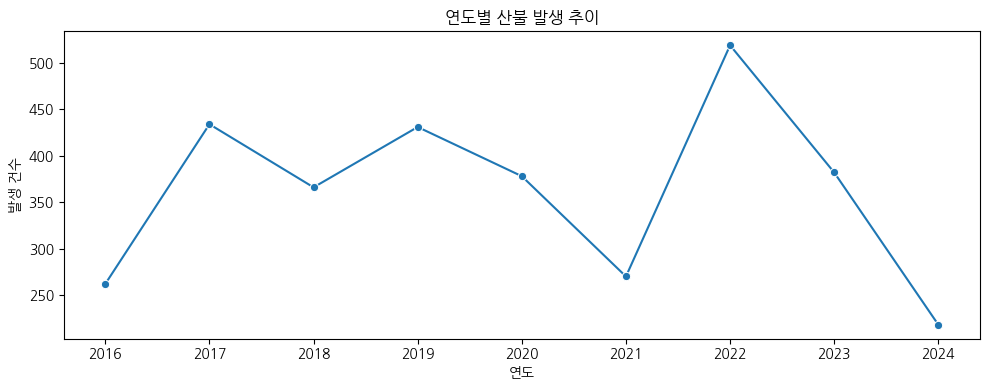

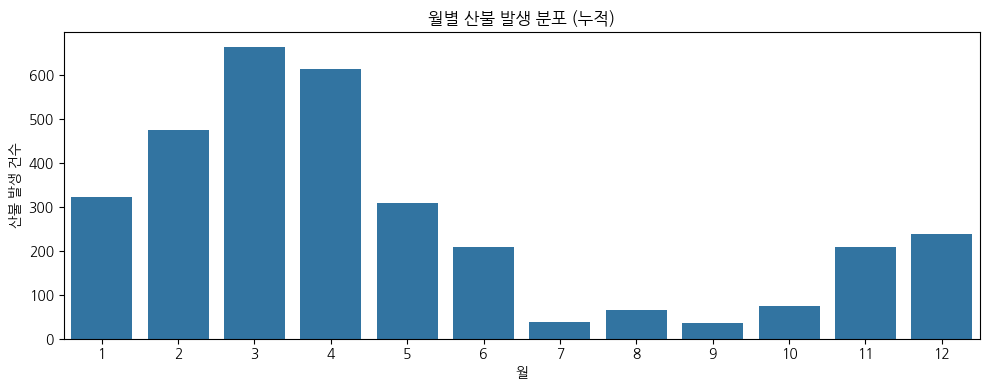

In [ ]:
# 연도별 시각화
plt.figure(figsize=(10, 4))
sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, marker='o')
plt.title('연도별 산불 발생 추이')
plt.xlabel('연도')
plt.ylabel('발생 건수')
plt.tight_layout()
plt.show()

# 월별 시각화
plt.figure(figsize=(10, 4))
sns.barplot(x=monthly_counts.index, y=monthly_counts.values)
plt.title('월별 산불 발생 분포 (누적)')
plt.xlabel('월')
plt.ylabel('산불 발생 건수')
plt.tight_layout()
plt.show()

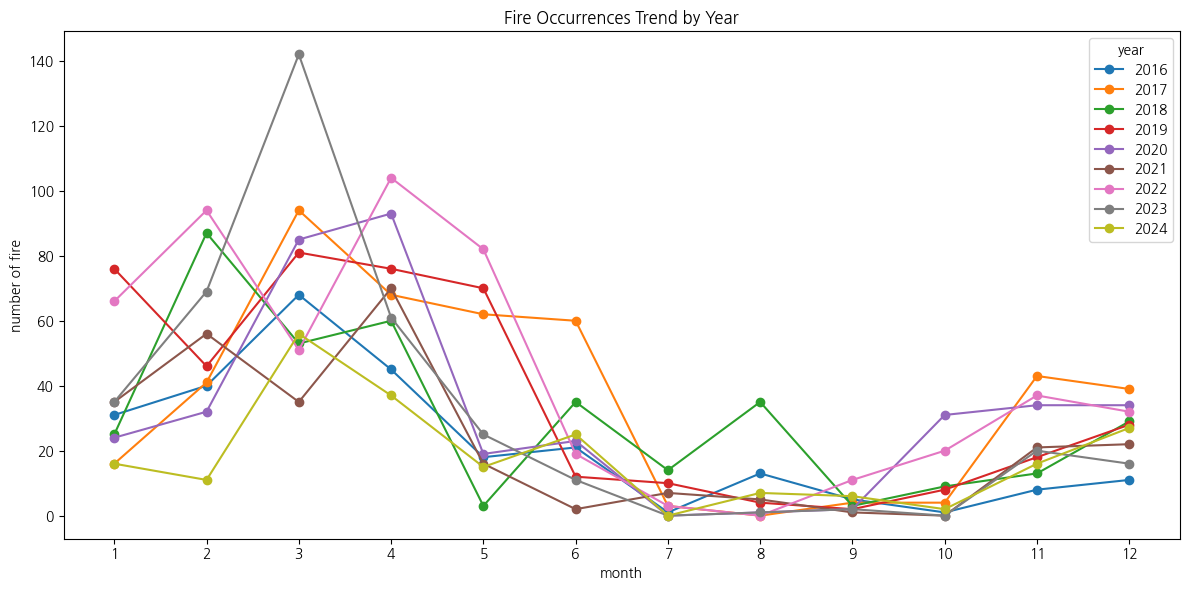

In [ ]:
# 피벗 테이블로 변환 (행: 월, 열: 연도)
pivot = monthly_trend.pivot(index='month', columns='year', values='count').fillna(0)

# 시각화
plt.figure(figsize=(12, 6))

for year in pivot.columns:
    plt.plot(pivot.index, pivot[year], marker='o', label=str(year))

plt.title('Fire Occurrences Trend by Year')
plt.xlabel('month')
plt.ylabel('number of fire')
plt.xticks(range(1, 13))
plt.legend(title='year')
plt.tight_layout()
plt.show()

In [ ]:
firedata

,date,region_group,일별_합계,산불발생여부,year,month,count
0,2016-01-01,강원,0,0,2016,1,31.0
1,2016-01-01,전북,0,0,2016,1,31.0
2,2016-01-01,대전/세종/충북,0,0,2016,1,31.0
3,2016-01-01,제주,0,0,2016,1,31.0
4,2016-01-01,대구/경북,0,0,2016,1,31.0
...,...,...,...,...,...,...,...
29587,2024-12-31,대전/세종/충북,0,0,2024,12,27.0
29588,2024-12-31,전북,0,0,2024,12,27.0
29589,2024-12-31,강원,0,0,2024,12,27.0
29590,2024-12-31,광주/전남,0,0,2024,12,27.0


In [ ]:
firedata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29592 entries, 0 to 29591
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          29592 non-null  datetime64[ns]
 1   region_group  29592 non-null  object        
 2   일별_합계         29592 non-null  int64         
 3   산불발생여부        29592 non-null  int64         
 4   year          29592 non-null  int32         
 5   month         29592 non-null  int32         
 6   count         27639 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int32(2), int64(2), object(1)
memory usage: 1.4+ MB


In [ ]:
# 왜 count가 결측값이....
firedata.isna().sum()

,0
date,0
region_group,0
일별_합계,0
산불발생여부,0
year,0
month,0
count,1953


##### 시각화

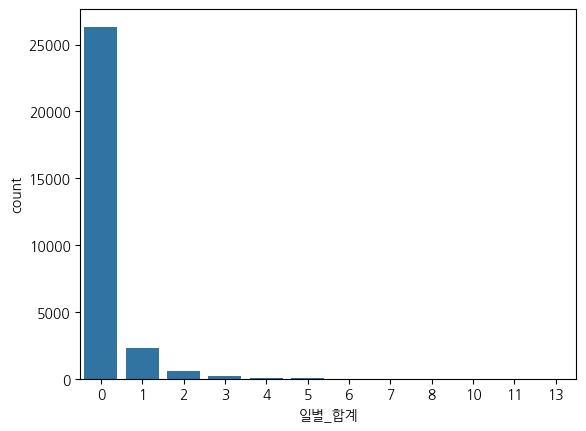

In [ ]:
sns.countplot(x="일별_합계", data=firedata)
plt.show()

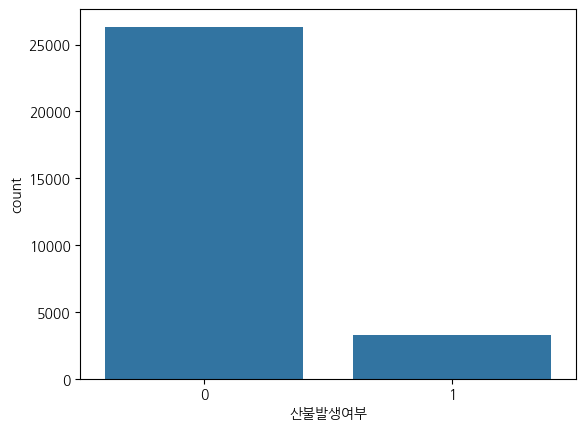

In [ ]:
sns.countplot(x="산불발생여부", data=firedata)
plt.show()

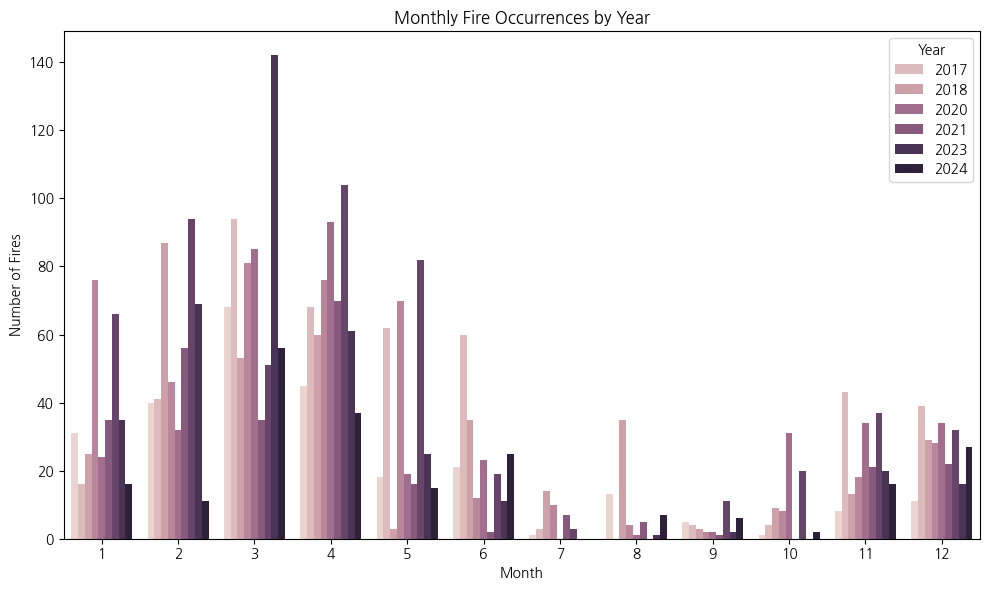

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='month', y='count', hue='year', data=monthly_trend)
plt.title('Monthly Fire Occurrences by Year')
plt.xlabel('Month')
plt.ylabel('Number of Fires')
plt.legend(title='Year')
plt.tight_layout()
plt.show()

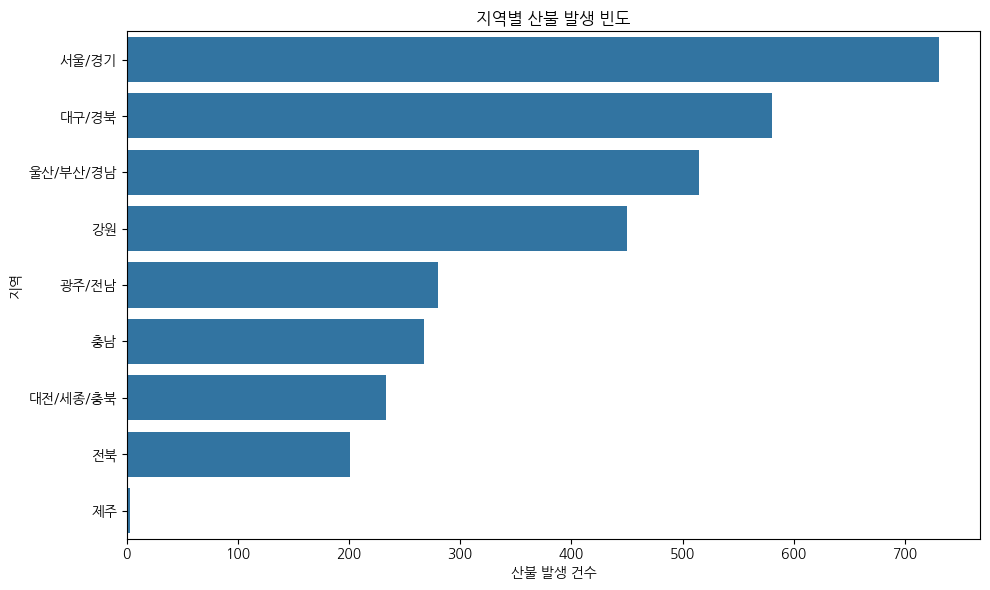

In [ ]:
# 지역별 산불 발생 빈도 계산
region_counts = firedata[firedata['산불발생여부'] == 1]['region_group'].value_counts().sort_values(ascending=False)

# 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x=region_counts.values, y=region_counts.index)
plt.title('지역별 산불 발생 빈도')
plt.xlabel('산불 발생 건수')
plt.ylabel('지역')
plt.tight_layout()
plt.show()

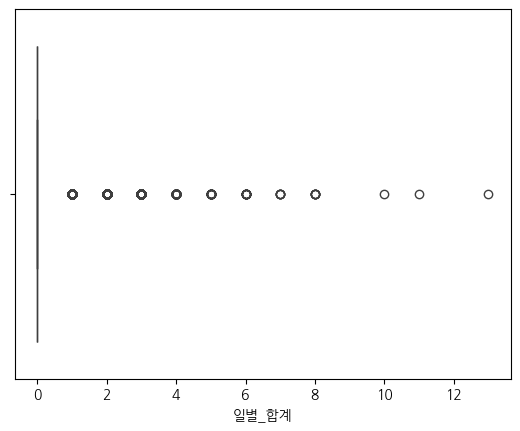

In [ ]:
sns.boxplot(data = firedata, x = '일별_합계')
plt.show()

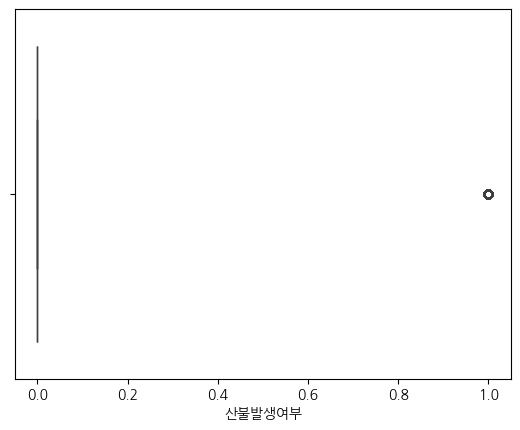

In [ ]:
sns.boxplot(data = firedata, x = '산불발생여부')
plt.show()

##### 상관관계 의미 있나...?

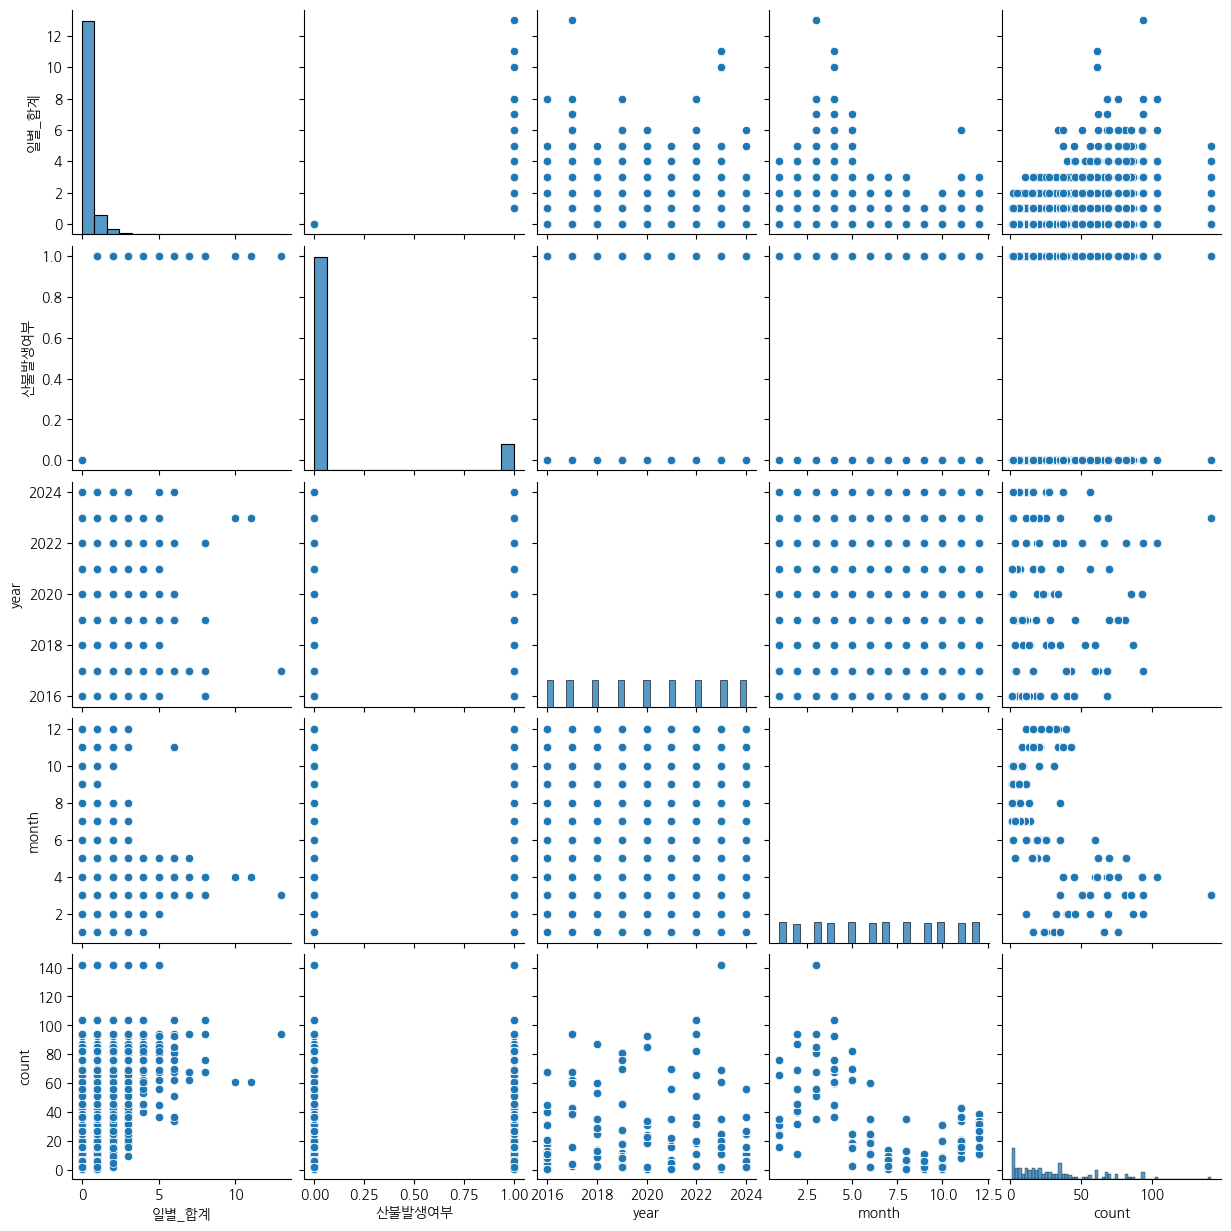

In [ ]:
sns.pairplot(firedata)
plt.show()

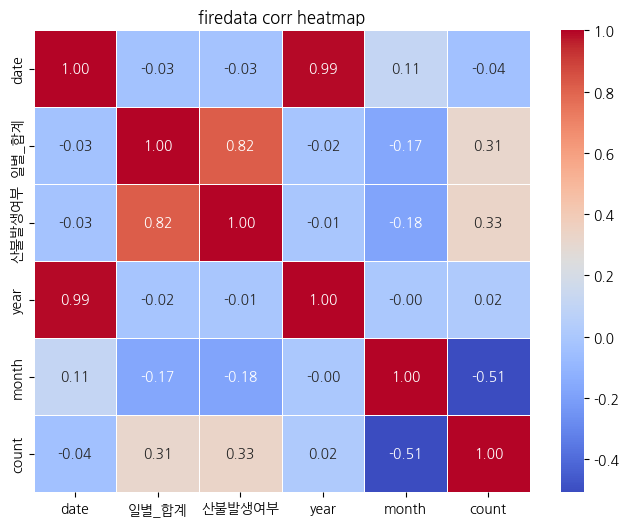

In [ ]:
# 상관관계 행렬 계산
correlation_matrix = firedata.drop(columns=['region_group']).corr()

# 히트맵 생성
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# 그래프 제목 추가
plt.title("firedata corr heatmap")
plt.show()

##### ADF 테스트 (정상성 여부 판단) 이게 하는게 맞나? 의미가 있나...?

In [ ]:
firedata

,date,region_group,일별_합계,산불발생여부,year,month,count
0,2016-01-01,강원,0,0,2016,1,31.0
1,2016-01-01,전북,0,0,2016,1,31.0
2,2016-01-01,대전/세종/충북,0,0,2016,1,31.0
3,2016-01-01,제주,0,0,2016,1,31.0
4,2016-01-01,대구/경북,0,0,2016,1,31.0
...,...,...,...,...,...,...,...
29587,2024-12-31,대전/세종/충북,0,0,2024,12,27.0
29588,2024-12-31,전북,0,0,2024,12,27.0
29589,2024-12-31,강원,0,0,2024,12,27.0
29590,2024-12-31,광주/전남,0,0,2024,12,27.0


In [ ]:
firedata_adf = firedata.set_index('date')

In [ ]:
firedata_adf

,region_group,일별_합계,산불발생여부,year,month,count
date,,,,,,
2016-01-01,강원,0,0,2016,1,31.0
2016-01-01,전북,0,0,2016,1,31.0
2016-01-01,대전/세종/충북,0,0,2016,1,31.0
2016-01-01,제주,0,0,2016,1,31.0
2016-01-01,대구/경북,0,0,2016,1,31.0
...,...,...,...,...,...,...
2024-12-31,대전/세종/충북,0,0,2024,12,27.0
2024-12-31,전북,0,0,2024,12,27.0
2024-12-31,강원,0,0,2024,12,27.0


In [ ]:
firedata_adf = firedata_adf.drop(columns=['region_group'])

In [ ]:
# 3. ADF 테스트 (정상성 여부 판단)
result = adfuller(firedata_adf['일별_합계'])

In [ ]:
# 4. 결과 출력
print("ADF 통계량:", result[0])
print("p-value:", result[1])
print("임계값:", result[4])

print("사용된 시차 수:", result[2])
print("관측값 수:", result[3])
print("결론: 정상성 여부 =>", "정상 (stationary)" if result[1] < 0.05 else "비정상 (non-stationary)")


ADF 통계량: -12.827924148784424
p-value: 5.958580098248766e-24
임계값: {'1%': np.float64(-3.430571352792055), '5%': np.float64(-2.861637831895505), '10%': np.float64(-2.5668220729421325)}
사용된 시차 수: 46
관측값 수: 29545
결론: 정상성 여부 => 정상 (stationary)


In [ ]:
# 3. ADF 테스트 (정상성 여부 판단)
result = adfuller(firedata_adf['산불발생여부'])

In [ ]:
# 4. 결과 출력
print("ADF 통계량:", result[0])
print("p-value:", result[1])
print("임계값:", result[4])

print("사용된 시차 수:", result[2])
print("관측값 수:", result[3])
print("결론: 정상성 여부 =>", "정상 (stationary)" if result[1] < 0.05 else "비정상 (non-stationary)")

ADF 통계량: -11.969845234247467
p-value: 3.9216933733723607e-22
임계값: {'1%': np.float64(-3.4305713827669417), '5%': np.float64(-2.8616378451430933), '10%': np.float64(-2.5668220799935066)}
사용된 시차 수: 50
관측값 수: 29541
결론: 정상성 여부 => 정상 (stationary)
